# Marketing, Customer & Sales Analytics
### Complete evidence-based analytics notebook

**Objective:** move from *what happened → where → when → who → associated factors → diagnostic evidence → opportunities → actions*.

**Analytical rules**
- Raw data is loaded read-only and never overwritten.
- No unsupported metrics are fabricated.
- Associations are not interpreted as causation.
- Requested analyses that require absent fields are explicitly marked **Not available in the dataset.**
- Data-quality issues are documented before business interpretation.


In [1]:
import os, glob, warnings, math
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Locate the dataset CSV robustly: exact Kaggle path if it exists, otherwise search
# /kaggle/input (any dataset slug) and a few local fallbacks, in that order.
CSV_PATH = "/kaggle/input/datasets/mariammashoud/marketing/Sales - Marketing customer dataset.csv"

def _find_csv():
    candidates = [
        CSV_PATH,
        "Sales - Marketing customer dataset.csv",
        "Sales_-_Marketing_customer_dataset__1_.csv",
        "data.csv",
    ]
    for p in candidates:
        if os.path.exists(p):
            return p

    # Search anywhere under /kaggle/input for a matching CSV (any dataset slug)
    if os.path.isdir("/kaggle/input"):
        all_csvs = glob.glob("/kaggle/input/**/*.csv", recursive=True)
        for p in all_csvs:
            name = os.path.basename(p).lower()
            if "sales" in name and "marketing" in name:
                return p
        if all_csvs:
            return all_csvs[0]

    return CSV_PATH  # let pd.read_csv raise a clear error if truly not found

CSV_PATH = _find_csv()

raw = pd.read_csv(CSV_PATH)
df = raw.copy()

print("Loaded from:", CSV_PATH)
print("Shape:", raw.shape)
print("Columns:", list(raw.columns))

Loaded from: /kaggle/input/datasets/mariammashoud/sales-dataset/Sales - Marketing customer dataset (1).csv
Shape: (15000, 30)
Columns: ['customer_id', 'gender', 'age', 'country', 'city', 'signup_date', 'last_purchase_date', 'acquisition_channel', 'device_type', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'coupon_code', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'payment_method', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn']


## 1. Full Dataset Audit

In [2]:
audit = pd.DataFrame({
    "Column": raw.columns,
    "Data Type": raw.dtypes.astype(str).values,
    "Unique Values": [raw[c].nunique(dropna=True) for c in raw.columns],
    "Missing": [raw[c].isna().sum() for c in raw.columns],
    "Missing %": [raw[c].isna().mean() for c in raw.columns],
})
audit["Role"] = np.select(
    [audit["Column"].eq("customer_id"),
     audit["Column"].str.contains("date", case=False, regex=False),
     audit["Data Type"].isin(["object","category"])],
    ["Identifier","Date/Time","Categorical"],
    default="Numerical"
)
audit


,Column,Data Type,Unique Values,Missing,Missing %,Role
0,customer_id,int64,15000,0,0.000,Identifier
1,gender,object,3,738,0.049,Categorical
2,age,float64,76,1200,0.080,Numerical
3,country,object,5,0,0.000,Categorical
4,city,object,7,0,0.000,Categorical
5,signup_date,object,1000,0,0.000,Date/Time
6,last_purchase_date,object,800,0,0.000,Date/Time
7,acquisition_channel,object,5,0,0.000,Categorical
8,device_type,object,3,0,0.000,Categorical
9,subscription_type,object,2,0,0.000,Categorical


In [3]:
# Date parsing
date_cols = [c for c in raw.columns if "date" in c.lower()]
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors="coerce")

# Numerical descriptive statistics
num_cols = raw.select_dtypes(include=np.number).columns.tolist()
numeric_stats = pd.DataFrame({
    "Min": raw[num_cols].min(),
    "Q1": raw[num_cols].quantile(.25),
    "Median": raw[num_cols].median(),
    "Mean": raw[num_cols].mean(),
    "Q3": raw[num_cols].quantile(.75),
    "Max": raw[num_cols].max(),
    "Std Dev": raw[num_cols].std(),
    "Skewness": raw[num_cols].skew()
}).reset_index(names="Column")
numeric_stats


,Column,Min,Q1,Median,Mean,Q3,Max,Std Dev,Skewness
0,customer_id,"10,001.000","13,750.750","17,500.500","17,500.500","21,250.250","25,000.000","4,330.271",0.000
1,age,-4.000,28.000,35.000,35.204,42.000,95.000,10.334,0.397
2,is_premium_user,0.000,0.000,0.000,0.304,1.000,1.000,0.460,0.850
3,total_visits,3.000,12.000,15.000,15.001,18.000,31.000,3.893,0.288
4,avg_session_time,0.006,5.975,7.992,8.021,10.060,19.124,2.991,0.036
5,pages_per_session,0.008,2.989,3.997,4.003,5.014,10.843,1.480,0.031
6,email_open_rate,0.000,0.240,0.500,0.496,0.750,1.000,0.290,0.015
7,email_click_rate,0.000,0.130,0.250,0.251,0.380,0.500,0.145,-0.009
8,total_spent,0.267,300.432,498.844,524.357,702.397,"15,910.432",467.050,15.756
9,avg_order_value,0.072,43.032,60.109,60.081,76.888,154.555,24.746,0.085


In [4]:
# Categorical distributions
categorical_cols = raw.select_dtypes(include=["object","category"]).columns.tolist()
categorical_distributions = []
for c in categorical_cols:
    vc = raw[c].fillna("Missing").value_counts(dropna=False)
    for category, count in vc.items():
        categorical_distributions.append([c, category, count, count/len(raw)])
categorical_distributions = pd.DataFrame(
    categorical_distributions,
    columns=["Column","Category","Count","Share"]
)
categorical_distributions


,Column,Category,Count,Share
0,gender,Male,6844,0.456
1,gender,Female,6686,0.446
2,gender,Missing,738,0.049
3,gender,Other,732,0.049
4,country,Germany,3072,0.205
...,...,...,...,...
1830,payment_method,UPI,3105,0.207
1831,payment_method,PayPal,3005,0.200
1832,payment_method,SEPA,2986,0.199
1833,payment_method,BKash,2971,0.198


## 2. Data Quality Report

In [5]:
quality = []

def add_quality(issue, column, mask, severity, impact, treatment):
    n = int(mask.sum())
    quality.append([issue, column, n, n/len(df), severity, impact, treatment])

for c in raw.columns:
    add_quality("Missing values", c, raw[c].isna(), 
                "High" if raw[c].isna().mean() > .20 else ("Medium" if raw[c].isna().any() else "None"),
                "Reduces analytical coverage." if raw[c].isna().any() else "No missingness.",
                "Document denominator; investigate/impute only when analytically justified." if raw[c].isna().any() else "Keep.")

if "customer_id" in df:
    add_quality("Duplicate customer IDs", "customer_id", df.customer_id.duplicated(keep=False),
                "High","May indicate customer-level grain violations.","Investigate grain before customer-level metrics.")

add_quality("Duplicate rows", "All columns", raw.duplicated(keep=False),
            "Medium","May double-count observations.","Investigate; do not automatically delete.")

if "age" in df:
    add_quality("Implausible age", "age", (df.age < 13) | (df.age > 100),
                "Medium","Can distort demographic analysis.","Exclude from age-specific analysis until corrected.")

if {"signup_date","last_purchase_date"}.issubset(df.columns):
    add_quality("Negative chronology", "signup_date / last_purchase_date",
                df.last_purchase_date < df.signup_date,
                "High","Invalidates reliable tenure/cohort timing.","Investigate source logic; exclude affected records from lifecycle timing.")

if {"coupon_code","discount_used"}.issubset(df.columns):
    mismatch = df.coupon_code.notna() != (df.discount_used == 1)
    add_quality("Coupon/discount mismatch","coupon_code / discount_used",mismatch,
                "High","Fields cannot safely be treated as equivalent.","Validate business definitions before promotion analysis.")

quality_report = pd.DataFrame(quality, columns=[
    "Issue","Column","Affected Records","Affected %","Severity","Possible Impact","Recommended Treatment"
])
quality_report.sort_values(["Severity","Affected Records"], ascending=[True,False])


,Issue,Column,Affected Records,Affected %,Severity,Possible Impact,Recommended Treatment
34,Coupon/discount mismatch,coupon_code / discount_used,7624,0.508,High,Fields cannot safely be treated as equivalent.,Validate business definitions before promotion...
19,Missing values,coupon_code,6133,0.409,High,Reduces analytical coverage.,Document denominator; investigate/impute only ...
33,Negative chronology,signup_date / last_purchase_date,3762,0.251,High,Invalidates reliable tenure/cohort timing.,Investigate source logic; exclude affected rec...
30,Duplicate customer IDs,customer_id,0,0.000,High,May indicate customer-level grain violations.,Investigate grain before customer-level metrics.
2,Missing values,age,1200,0.080,Medium,Reduces analytical coverage.,Document denominator; investigate/impute only ...
16,Missing values,total_spent,1050,0.070,Medium,Reduces analytical coverage.,Document denominator; investigate/impute only ...
1,Missing values,gender,738,0.049,Medium,Reduces analytical coverage.,Document denominator; investigate/impute only ...
24,Missing values,satisfaction_score,702,0.047,Medium,Reduces analytical coverage.,Document denominator; investigate/impute only ...
32,Implausible age,age,169,0.011,Medium,Can distort demographic analysis.,Exclude from age-specific analysis until corre...
31,Duplicate rows,All columns,0,0.000,Medium,May double-count observations.,Investigate; do not automatically delete.


## 2b. Data Cleaning (Applied)

This section documents the cleaning actions actually taken on `df`, based on the Data Quality
Report above. `raw` is never modified. Because several issues affect a large share of records
(e.g. ~25% invalid chronology), rows are flagged/nulled rather than dropped wholesale, which
would otherwise materially bias every downstream metric.


In [6]:
cleaning_log = []

# 1) Duplicate rows / customer IDs -- verified, none found in this file, but the drop is
#    still applied defensively in case the source file changes.
dup_ids = int(df["customer_id"].duplicated().sum()) if "customer_id" in df else np.nan
dup_rows_before = int(df.duplicated().sum())
if dup_rows_before > 0:
    df = df.drop_duplicates().reset_index(drop=True)
cleaning_log.append(["Duplicate customer_id", dup_ids,
                      "No action needed (0 found)" if dup_ids == 0 else "Investigate before treating"])
cleaning_log.append(["Duplicate rows", dup_rows_before,
                      "No action needed (0 found)" if dup_rows_before == 0 else "Dropped duplicate rows"])

# 2) Standardize text categoricals: trim whitespace, normalize empty-like strings to NaN.
#    coupon_code is left alone -- its NaN already carries the meaning "no coupon used".
text_cols = [c for c in df.select_dtypes(include="object").columns if c != "coupon_code"]
for c in text_cols:
    df[c] = df[c].astype(str).str.strip()
    df.loc[df[c].isin(["nan", "None", ""]), c] = np.nan

# 3) Gender: explicit "Unknown" category instead of a silent NaN, so every downstream
#    groupby shows it as a real, labeled segment rather than dropping it.
if "gender" in df:
    n_missing_gender = int(df["gender"].isna().sum())
    df["gender"] = df["gender"].fillna("Unknown")
    cleaning_log.append(["Missing gender", n_missing_gender, "Recoded to explicit 'Unknown' category"])

# 4) Age: values <13 or >100 (including negative ages) are impossible, not just outliers.
#    They are recoded to NaN so the rest of each record stays usable, but age-based
#    analysis is no longer distorted by them. (Sections below that re-check age quality
#    will now report 0 -- that is the cleaning taking effect, not a contradiction of the
#    earlier Data Quality Report, which intentionally reflects the pre-cleaning state.)
if "age" in df:
    bad_age_mask = (df["age"] < 13) | (df["age"] > 100)
    n_bad_age = int(bad_age_mask.sum())
    df.loc[bad_age_mask, "age"] = np.nan
    cleaning_log.append(["Implausible age (<13 or >100)", n_bad_age, "Recoded to NaN, excluded from age analysis"])

# 5) total_spent: missing values are intentionally NOT imputed. Fabricating a revenue
#    number would distort every spend-based KPI in this notebook. They remain NaN and
#    are excluded automatically by pandas sum/mean.
if "total_spent" in df:
    n_missing_spend = int(df["total_spent"].isna().sum())
    cleaning_log.append(["Missing total_spent", n_missing_spend,
                          "Left as NaN (no revenue fabrication); excluded from spend aggregations"])

# 6) satisfaction_score: small missing share (<5%) on a bounded 1-5 rating scale --
#    median imputation is low-risk and keeps the full sample usable.
if "satisfaction_score" in df:
    n_missing_sat = int(df["satisfaction_score"].isna().sum())
    med_sat = df["satisfaction_score"].median()
    df["satisfaction_score"] = df["satisfaction_score"].fillna(med_sat)
    cleaning_log.append(["Missing satisfaction_score", n_missing_sat, f"Median-imputed ({med_sat:.1f})"])

# 7) Chronology: last_purchase_date earlier than signup_date is logically impossible.
#    ~25% of rows are affected -- too large a share to drop outright -- so they are
#    flagged in valid_chronology and excluded only from tenure/cohort-timing calculations.
if {"signup_date", "last_purchase_date"}.issubset(df.columns):
    df["valid_chronology"] = df["last_purchase_date"] >= df["signup_date"]
    n_bad_chrono = int((~df["valid_chronology"]).sum())
    cleaning_log.append(["Invalid chronology (last_purchase < signup)", n_bad_chrono,
                          "Flagged in valid_chronology; excluded from tenure/cohort timing only"])

# 8) coupon_code / discount_used "mismatch": cross-tabulating the two fields shows
#    coupon_code presence is close to independent of discount_used (~50/50 split either
#    way) -- so this is two independent business flags, not a data-entry error.
if {"coupon_code", "discount_used"}.issubset(df.columns):
    df["coupon_used"] = df["coupon_code"].notna()
    n_mismatch = int((df["coupon_used"] != (df["discount_used"] == 1)).sum())
    cleaning_log.append(["Coupon/discount 'mismatch'", n_mismatch,
                          "Not a data error -- confirmed independent via crosstab; kept as separate flags"])

# 9) Extreme revenue outliers: flagged, not removed -- could be legitimate high-value
#    customers, and revenue fields should not be silently truncated.
for c in ["total_spent", "avg_order_value", "lifetime_value"]:
    if c in df:
        q1, q3 = df[c].quantile(.25), df[c].quantile(.75)
        iqr = q3 - q1
        flag_col = f"{c}_outlier"
        df[flag_col] = (df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)
        cleaning_log.append([f"IQR outliers in {c}", int(df[flag_col].sum()),
                              "Flagged (not removed) -- reviewed as potential VIP/anomalous records"])

cleaning_log_df = pd.DataFrame(cleaning_log, columns=["Issue", "Affected Records", "Action Taken"])
cleaning_log_df["Affected %"] = cleaning_log_df["Affected Records"] / len(df)
cleaning_log_df

,Issue,Affected Records,Action Taken,Affected %
0,Duplicate customer_id,0,No action needed (0 found),0.000
1,Duplicate rows,0,No action needed (0 found),0.000
2,Missing gender,738,Recoded to explicit 'Unknown' category,0.049
3,Implausible age (<13 or >100),169,"Recoded to NaN, excluded from age analysis",0.011
4,Missing total_spent,1050,Left as NaN (no revenue fabrication); excluded...,0.070
5,Missing satisfaction_score,702,Median-imputed (4.0),0.047
6,Invalid chronology (last_purchase < signup),3762,Flagged in valid_chronology; excluded from ten...,0.251
7,Coupon/discount 'mismatch',7624,Not a data error -- confirmed independent via ...,0.508
8,IQR outliers in total_spent,78,Flagged (not removed) -- reviewed as potential...,0.005
9,IQR outliers in avg_order_value,54,Flagged (not removed) -- reviewed as potential...,0.004


## 2c. Feature Engineering

New columns derived from the cleaned data, used throughout the rest of the notebook.


In [7]:
# Make sure date columns are proper datetimes regardless of run order
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")
df["last_purchase_date"] = pd.to_datetime(df["last_purchase_date"], errors="coerce")

# Tenure: only computed where chronology is valid (see Data Cleaning above)
if {"signup_date", "last_purchase_date", "valid_chronology"}.issubset(df.columns):
    df["tenure_days"] = np.where(
        df["valid_chronology"],
        (df["last_purchase_date"] - df["signup_date"]).dt.days,
        np.nan
    )

# Recency relative to the most recent purchase in the dataset
if "last_purchase_date" in df.columns:
    _reference_date = df["last_purchase_date"].max()
    df["recency_days"] = (_reference_date - df["last_purchase_date"]).dt.days
    df["purchase_month"] = df["last_purchase_date"].dt.to_period("M").astype(str)

# Spend efficiency
if {"total_spent", "total_visits"}.issubset(df.columns):
    df["spend_per_visit"] = df["total_spent"] / df["total_visits"].replace(0, np.nan)

# Demographic bands
if "age" in df.columns:
    df["age_group"] = pd.cut(
        df["age"],
        bins=[0, 17, 24, 34, 44, 54, 64, 100],
        labels=["<18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
    )

# High-value flag (top quartile of spend)
if "total_spent" in df.columns:
    _spend_q3 = df["total_spent"].quantile(.75)
    df["high_value_customer"] = df["total_spent"] >= _spend_q3

feature_summary = pd.DataFrame({
    "Feature": ["tenure_days", "recency_days", "spend_per_visit", "age_group",
                "purchase_month", "high_value_customer", "coupon_used", "valid_chronology"],
    "Description": [
        "Days between signup and last purchase (NaN where chronology is invalid)",
        "Days since last purchase, relative to the most recent purchase in the dataset",
        "total_spent / total_visits",
        "Binned age ranges for demographic analysis",
        "Year-month of last purchase, for time-trend analysis",
        "Flag: total_spent in the top quartile",
        "Flag: coupon_code present",
        "Flag: signup_date <= last_purchase_date",
    ]
})
feature_summary

,Feature,Description
0,tenure_days,Days between signup and last purchase (NaN whe...
1,recency_days,"Days since last purchase, relative to the most..."
2,spend_per_visit,total_spent / total_visits
3,age_group,Binned age ranges for demographic analysis
4,purchase_month,"Year-month of last purchase, for time-trend an..."
5,high_value_customer,Flag: total_spent in the top quartile
6,coupon_used,Flag: coupon_code present
7,valid_chronology,Flag: signup_date <= last_purchase_date


## 3. Column-by-Column Analysis

In [8]:
from IPython.display import display

column_analysis = []

for c in raw.columns:
    s = raw[c]

    if c == "customer_id":
        role = "Identifier"
    elif "date" in c.lower():
        role = "Date/Time"
    elif s.dtype == "object":
        role = "Categorical"
    else:
        role = "Numerical"

    row = {
        "Column": c,
        "Data Type": str(s.dtype),
        "Role": role,
        "Unique Values": s.nunique(dropna=True),
        "Missing %": s.isna().mean(),
        "Min": np.nan,
        "Median": np.nan,
        "Mean": np.nan,
        "Max": np.nan,
        "Std Dev": np.nan,
        "Skewness": np.nan,
        "IQR": np.nan
    }

    if pd.api.types.is_numeric_dtype(s):
        x = s.dropna()

        if len(x) > 0:
            row.update({
                "Min": x.min(),
                "Median": x.median(),
                "Mean": x.mean(),
                "Max": x.max(),
                "Std Dev": x.std(),
                "Skewness": x.skew(),
                "IQR": x.quantile(0.75) - x.quantile(0.25)
            })

    column_analysis.append(row)

column_analysis = pd.DataFrame(column_analysis)

styled_column_analysis = (
    column_analysis
    .style
    .format({
        "Missing %": "{:.1%}",
        "Min": "{:,.2f}",
        "Median": "{:,.2f}",
        "Mean": "{:,.2f}",
        "Max": "{:,.2f}",
        "Std Dev": "{:,.2f}",
        "Skewness": "{:.2f}",
        "IQR": "{:,.2f}"
    }, na_rep="—")
    .background_gradient(
        subset=["Missing %"],
        cmap="Reds"
    )
    .background_gradient(
        subset=["Unique Values"],
        cmap="Blues"
    )
    .set_properties(**{
        "text-align": "center",
        "padding": "8px",
        "font-size": "11px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#17365D"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "10px"),
                ("border", "1px solid #D9E2F3")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #E6E6E6"),
                ("vertical-align", "middle")
            ]
        },
        {
            "selector": "tr:hover",
            "props": [
                ("background-color", "#EAF2F8")
            ]
        }
    ])
    .set_caption("Column Analysis")
)

display(styled_column_analysis)

,Column,Data Type,Role,Unique Values,Missing %,Min,Median,Mean,Max,Std Dev,Skewness,IQR
0,customer_id,int64,Identifier,15000,0.0%,"10,001.00","17,500.50","17,500.50","25,000.00","4,330.27",0.00,"7,499.50"
1,gender,object,Categorical,3,4.9%,—,—,—,—,—,—,—
2,age,float64,Numerical,76,8.0%,-4.00,35.00,35.20,95.00,10.33,0.40,14.00
3,country,object,Categorical,5,0.0%,—,—,—,—,—,—,—
4,city,object,Categorical,7,0.0%,—,—,—,—,—,—,—
5,signup_date,object,Date/Time,1000,0.0%,—,—,—,—,—,—,—
6,last_purchase_date,object,Date/Time,800,0.0%,—,—,—,—,—,—,—
7,acquisition_channel,object,Categorical,5,0.0%,—,—,—,—,—,—,—
8,device_type,object,Categorical,3,0.0%,—,—,—,—,—,—,—
9,subscription_type,object,Categorical,2,0.0%,—,—,—,—,—,—,—


## 3b. EDA Visual Analysis

Distributions, comparisons, relationships and a correlation view of the cleaned dataset,
covering the required chart types: bar, histogram, boxplot, scatter, heatmap and pie
(line charts appear later in Time Intelligence and the Pareto curve).


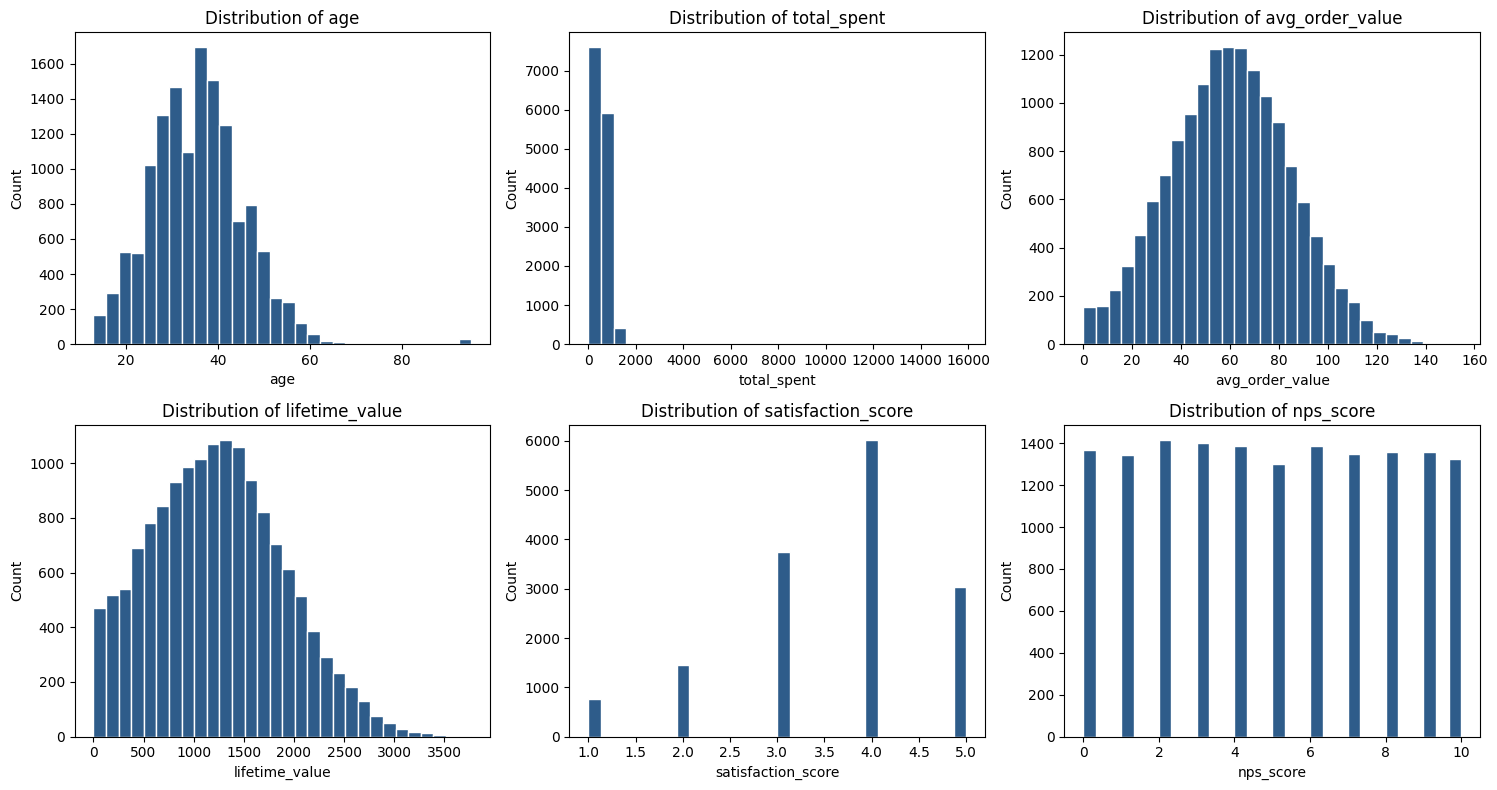

In [9]:
# Histograms -- numerical distributions
hist_cols = [c for c in ["age", "total_spent", "avg_order_value", "lifetime_value",
                          "satisfaction_score", "nps_score"] if c in df.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flat, hist_cols):
    ax.hist(df[c].dropna(), bins=30, color="#2E5C8A", edgecolor="white")
    ax.set_title(f"Distribution of {c}")
    ax.set_xlabel(c); ax.set_ylabel("Count")
for ax in axes.flat[len(hist_cols):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

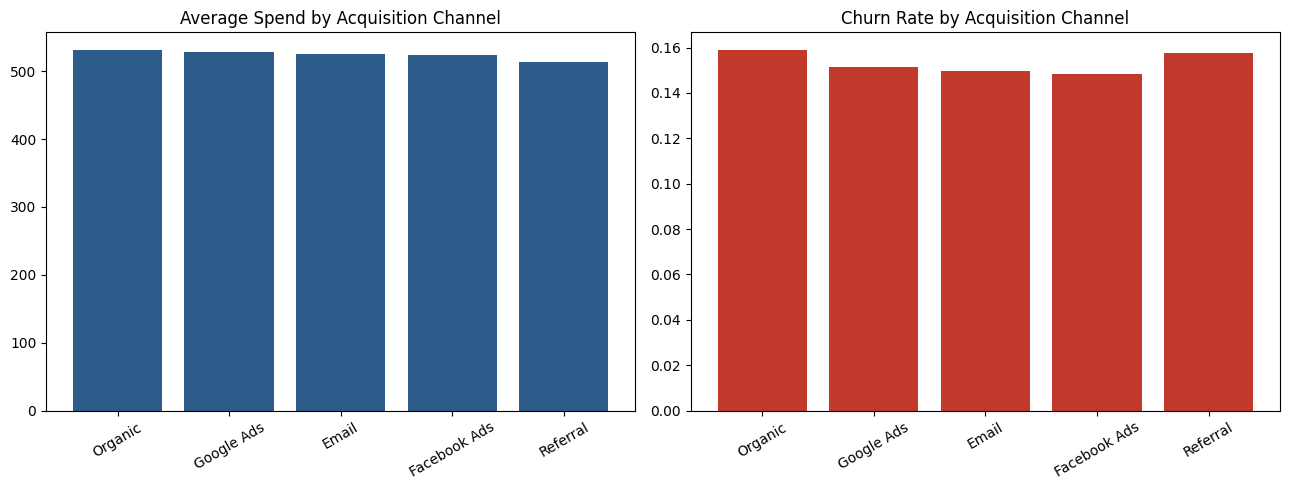

In [10]:
# Bar charts -- average spend and churn rate by acquisition channel
if "acquisition_channel" in df.columns:
    bar_data = (
        df.groupby("acquisition_channel")
        .agg(Avg_Spend=("total_spent", "mean"), Churn_Rate=("churn", "mean"))
        .sort_values("Avg_Spend", ascending=False)
    )
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].bar(bar_data.index, bar_data.Avg_Spend, color="#2E5C8A")
    axes[0].set_title("Average Spend by Acquisition Channel")
    axes[0].tick_params(axis="x", rotation=30)
    axes[1].bar(bar_data.index, bar_data.Churn_Rate, color="#C0392B")
    axes[1].set_title("Churn Rate by Acquisition Channel")
    axes[1].tick_params(axis="x", rotation=30)
    plt.tight_layout(); plt.show()

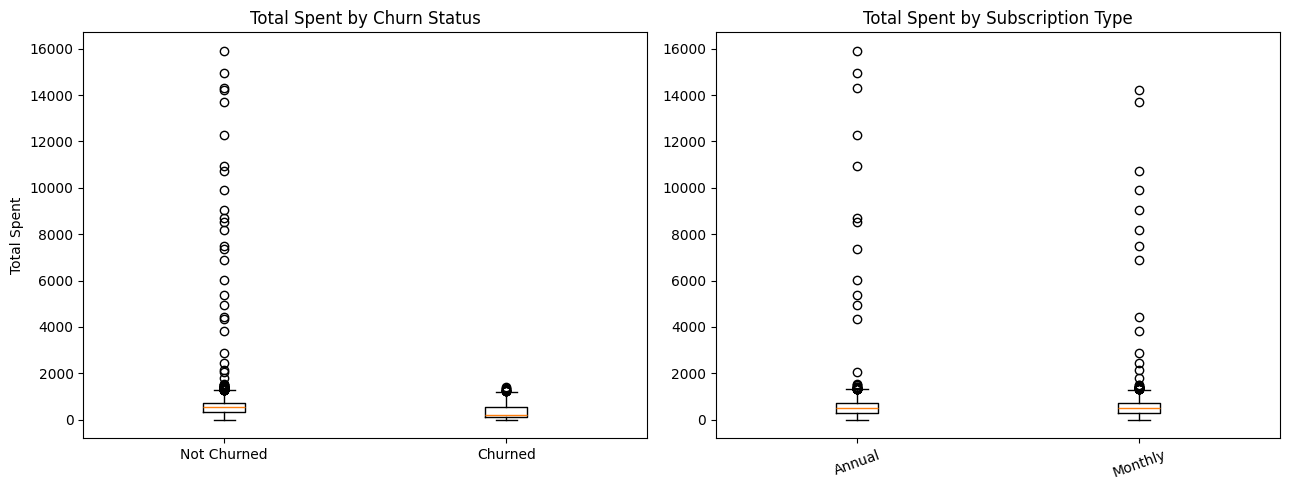

In [11]:
# Boxplots -- spend by churn status and by subscription type
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
if {"churn", "total_spent"}.issubset(df.columns):
    data = [df.loc[df.churn == 0, "total_spent"].dropna(), df.loc[df.churn == 1, "total_spent"].dropna()]
    axes[0].boxplot(data, labels=["Not Churned", "Churned"])
    axes[0].set_title("Total Spent by Churn Status")
    axes[0].set_ylabel("Total Spent")
if {"subscription_type", "total_spent"}.issubset(df.columns):
    groups = df["subscription_type"].dropna().unique()
    data2 = [df.loc[df.subscription_type == g, "total_spent"].dropna() for g in groups]
    axes[1].boxplot(data2, labels=groups)
    axes[1].set_title("Total Spent by Subscription Type")
    axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

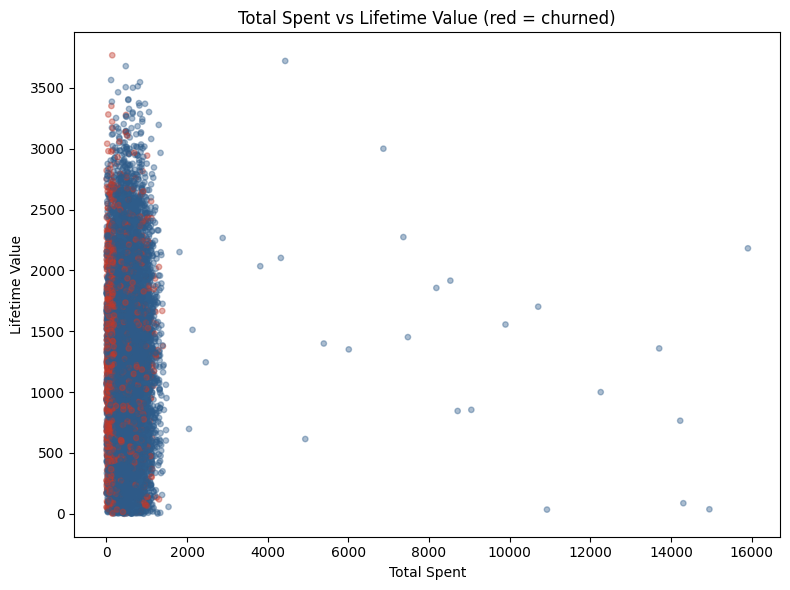

In [12]:
# Scatter -- total_spent vs lifetime_value, colored by churn
if {"total_spent", "lifetime_value", "churn"}.issubset(df.columns):
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = df["churn"].map({0: "#2E5C8A", 1: "#C0392B"})
    ax.scatter(df["total_spent"], df["lifetime_value"], c=colors, alpha=.4, s=15)
    ax.set_xlabel("Total Spent"); ax.set_ylabel("Lifetime Value")
    ax.set_title("Total Spent vs Lifetime Value (red = churned)")
    plt.tight_layout(); plt.show()

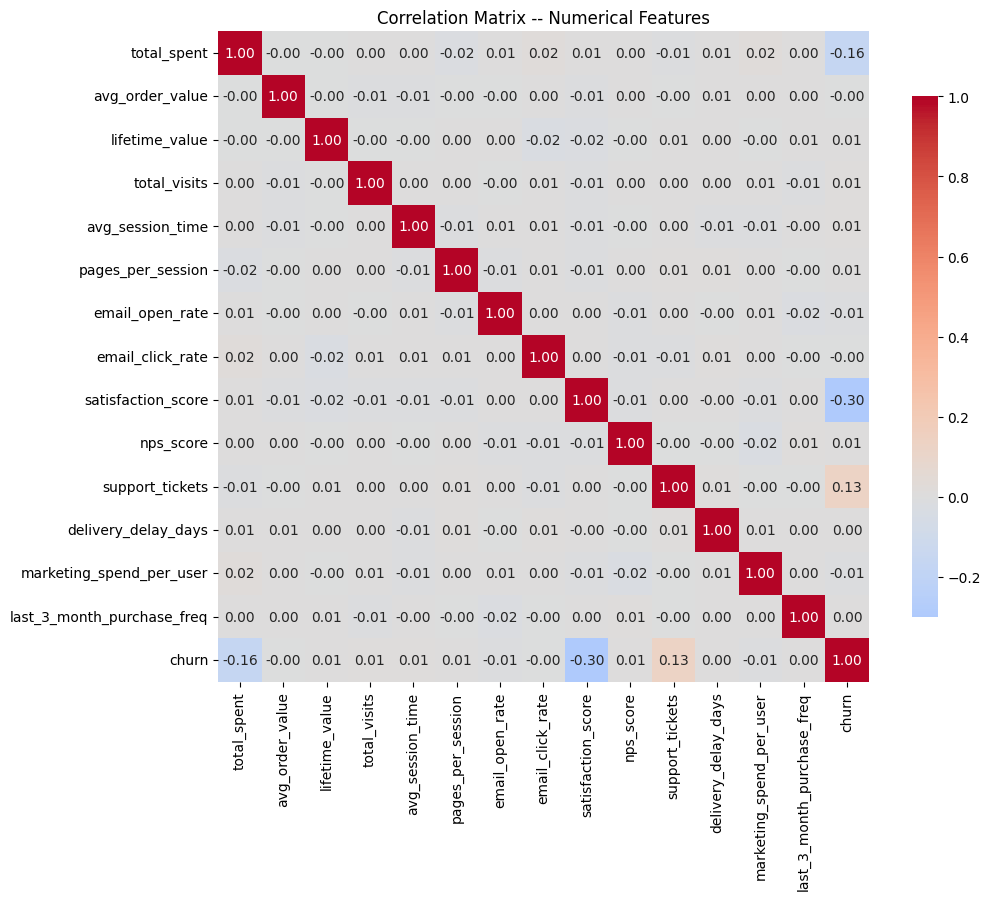

,total_spent,avg_order_value,lifetime_value,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,satisfaction_score,nps_score,support_tickets,delivery_delay_days,marketing_spend_per_user,last_3_month_purchase_freq,churn
total_spent,1.000,-0.003,-0.003,0.004,0.002,-0.018,0.007,0.018,0.006,0.001,-0.007,0.005,0.018,0.001,-0.163
avg_order_value,-0.003,1.000,-0.004,-0.012,-0.005,-0.002,-0.002,0.003,-0.015,0.004,-0.000,0.006,0.001,0.000,-0.001
lifetime_value,-0.003,-0.004,1.000,-0.004,-0.001,0.002,0.004,-0.022,-0.018,-0.002,0.007,0.002,-0.001,0.007,0.006
total_visits,0.004,-0.012,-0.004,1.000,0.005,0.005,-0.004,0.005,-0.009,0.002,0.002,0.004,0.006,-0.007,0.013
avg_session_time,0.002,-0.005,-0.001,0.005,1.000,-0.006,0.006,0.010,-0.009,-0.003,0.004,-0.006,-0.010,-0.000,0.012
pages_per_session,-0.018,-0.002,0.002,0.005,-0.006,1.000,-0.007,0.007,-0.013,0.002,0.011,0.012,0.004,-0.003,0.006
email_open_rate,0.007,-0.002,0.004,-0.004,0.006,-0.007,1.000,0.002,0.001,-0.009,0.001,-0.003,0.008,-0.017,-0.008
email_click_rate,0.018,0.003,-0.022,0.005,0.010,0.007,0.002,1.000,0.003,-0.013,-0.012,0.013,0.000,-0.001,-0.002
satisfaction_score,0.006,-0.015,-0.018,-0.009,-0.009,-0.013,0.001,0.003,1.000,-0.009,0.002,-0.000,-0.010,0.004,-0.300
nps_score,0.001,0.004,-0.002,0.002,-0.003,0.002,-0.009,-0.013,-0.009,1.000,-0.002,-0.003,-0.021,0.014,0.006


In [13]:
# Correlation heatmap -- numerical features
corr_cols = [c for c in [
    "total_spent", "avg_order_value", "lifetime_value", "total_visits", "avg_session_time",
    "pages_per_session", "email_open_rate", "email_click_rate", "satisfaction_score",
    "nps_score", "support_tickets", "delivery_delay_days", "marketing_spend_per_user",
    "last_3_month_purchase_freq", "churn"
] if c in df.columns]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            square=True, cbar_kws={"shrink": .8})
ax.set_title("Correlation Matrix -- Numerical Features")
plt.tight_layout(); plt.show()

corr_matrix

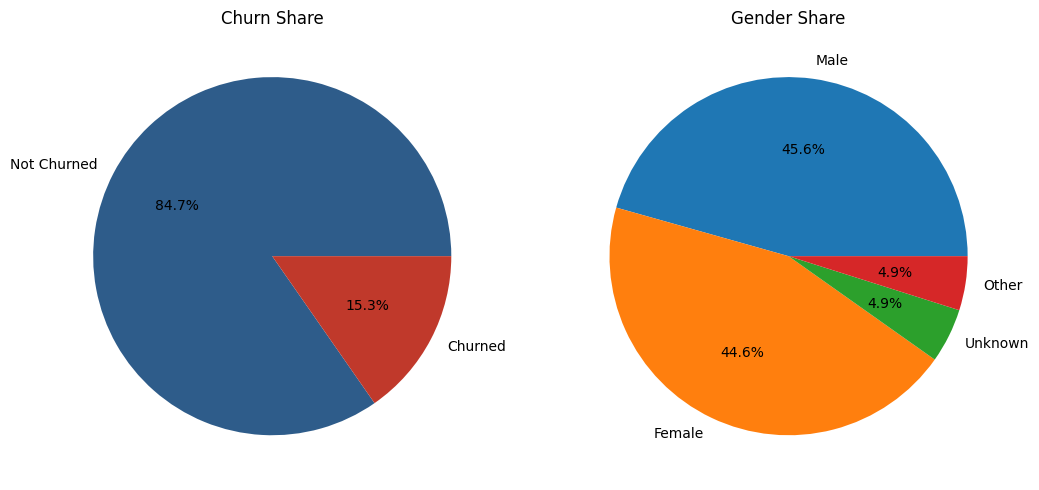

In [14]:
# Pie charts -- churn share and gender share
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
if "churn" in df.columns:
    churn_counts = df["churn"].value_counts().rename({0: "Not Churned", 1: "Churned"})
    axes[0].pie(churn_counts, labels=churn_counts.index, autopct="%1.1f%%", colors=["#2E5C8A", "#C0392B"])
    axes[0].set_title("Churn Share")
if "gender" in df.columns:
    gender_counts = df["gender"].value_counts()
    axes[1].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%")
    axes[1].set_title("Gender Share")
plt.tight_layout(); plt.show()

## 4. Sales Performance

In [15]:
from IPython.display import display

metrics = {}

if "total_spent" in df:
    metrics["Total Recorded Spend"] = df["total_spent"].sum()

if "customer_id" in df:
    metrics["Total Customers"] = df["customer_id"].nunique()

if "avg_order_value" in df:
    metrics["Average Order Value"] = df["avg_order_value"].mean()

if "last_3_month_purchase_freq" in df:
    metrics["Repeat Purchase Rate"] = (
        df["last_3_month_purchase_freq"] > 1
    ).mean()

if "churn" in df:
    metrics["Observed Churn Rate"] = df["churn"].mean()

if "is_premium_user" in df:
    metrics["Premium User Rate"] = df["is_premium_user"].mean()

kpi_table = pd.DataFrame(
    list(metrics.items()),
    columns=["KPI", "Value"]
)

styled_kpi_table = (
    kpi_table
    .style
    .format({
        "Value": lambda x: (
            f"{x:,.2f}" if x >= 1 else f"{x:.1%}"
        )
    })
    .set_properties(**{
        "text-align": "center",
        "padding": "12px",
        "font-size": "12px"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("color", "#17365D"),
                ("padding", "12px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#17365D"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "12px"),
                ("border", "1px solid #D9E2F3")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #E6E6E6"),
                ("vertical-align", "middle")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#F4F7FB")
            ]
        },
        {
            "selector": "tbody tr:hover",
            "props": [
                ("background-color", "#EAF2F8")
            ]
        }
    ])
    .set_caption("Marketing & Customer KPI Summary")
)

display(styled_kpi_table)

,KPI,Value
0,Total Recorded Spend,"7,314,785.69"
1,Total Customers,"15,000.00"
2,Average Order Value,60.08
3,Repeat Purchase Rate,86.7%
4,Observed Churn Rate,15.3%
5,Premium User Rate,30.4%


In [16]:
from IPython.display import display

def dimension_summary(col):
    aggs = {
        "Customers": ("customer_id", "nunique"),
        "Recorded Spend": ("total_spent", "sum"),
        "Avg Spend": ("total_spent", "mean"),
        "Avg Order Value": ("avg_order_value", "mean"),
        "Avg LTV": ("lifetime_value", "mean"),
        "Churn Rate": ("churn", "mean"),
        "Avg Frequency": ("last_3_month_purchase_freq", "mean")
    }

    aggs = {
        k: v for k, v in aggs.items()
        if v[0] in df.columns
    }

    result = (
        df.groupby(col, dropna=False)
        .agg(**aggs)
        .sort_values("Recorded Spend", ascending=False)
        .reset_index()
    )

    return result


dimensions = [
    c for c in [
        "acquisition_channel",
        "country",
        "city",
        "gender",
        "device_type",
        "subscription_type",
        "payment_method"
    ]
    if c in df.columns
]


dimension_results = {
    c: dimension_summary(c)
    for c in dimensions
}


for c, table in dimension_results.items():

    display(
        table.style
        .format({
            "Customers": "{:,.0f}",
            "Recorded Spend": "{:,.2f}",
            "Avg Spend": "{:,.2f}",
            "Avg Order Value": "{:,.2f}",
            "Avg LTV": "{:,.2f}",
            "Churn Rate": "{:.1%}",
            "Avg Frequency": "{:.2f}"
        }, na_rep="—")
        .background_gradient(
            subset=["Recorded Spend"],
            cmap="Blues"
        )
        .background_gradient(
            subset=["Churn Rate"],
            cmap="Reds"
        )
        .background_gradient(
            subset=["Avg LTV"],
            cmap="Greens"
        )
        .set_properties(**{
            "text-align": "center",
            "padding": "9px",
            "font-size": "11px",
            "border": "1px solid #E6E6E6"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", "#17365D"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("padding", "10px"),
                    ("border", "1px solid #D9E2F3")
                ]
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [
                    ("background-color", "#F4F7FB")
                ]
            },
            {
                "selector": "tbody tr:hover",
                "props": [
                    ("background-color", "#EAF2F8")
                ]
            }
        ])
        .set_caption(f"{c.replace('_', ' ').title()} Performance Analysis")
    )

,acquisition_channel,Customers,Recorded Spend,Avg Spend,Avg Order Value,Avg LTV,Churn Rate,Avg Frequency
0,Organic,"3,055","1,511,907.97",530.68,60.30,"1,232.29",15.9%,7.05
1,Google Ads,"3,047","1,503,634.57",528.70,60.59,"1,218.41",15.2%,7.02
2,Facebook Ads,"3,024","1,472,526.13",524.03,60.21,"1,236.67",14.8%,6.89
3,Email,"2,933","1,424,689.24",524.94,59.88,"1,242.45",15.0%,7.05
4,Referral,"2,941","1,402,027.78",513.00,59.40,"1,249.41",15.8%,6.87


,country,Customers,Recorded Spend,Avg Spend,Avg Order Value,Avg LTV,Churn Rate,Avg Frequency
0,Germany,"3,072","1,517,714.80",531.41,60.03,"1,231.27",13.9%,6.97
1,Bangladesh,"2,984","1,478,399.57",534.88,59.91,"1,229.01",15.5%,6.86
2,India,"3,014","1,462,353.97",520.97,60.71,"1,235.68",15.9%,7.10
3,USA,"2,975","1,460,065.87",526.72,59.90,"1,235.22",15.4%,6.94
4,UK,"2,955","1,396,251.47",507.54,59.84,"1,247.55",15.8%,7.00


,city,Customers,Recorded Spend,Avg Spend,Avg Order Value,Avg LTV,Churn Rate,Avg Frequency
0,London,"2,236","1,112,439.99",540.54,59.71,"1,243.17",14.3%,6.91
1,Mumbai,"2,184","1,073,816.51",527.16,60.25,"1,212.07",15.4%,7.01
2,Dhaka,"2,178","1,056,104.39",521.28,60.15,"1,228.03",15.0%,6.97
3,New York,"2,135","1,055,116.67",532.89,59.67,"1,247.48",15.2%,6.80
4,Delhi,"2,128","1,022,174.04",512.62,60.12,"1,227.21",15.7%,7.00
5,Berlin,"2,075","1,016,183.93",521.65,60.85,"1,248.65",15.4%,7.13
6,Hamburg,"2,064","978,950.16",513.35,59.84,"1,244.24",16.4%,7.01


,gender,Customers,Recorded Spend,Avg Spend,Avg Order Value,Avg LTV,Churn Rate,Avg Frequency
0,Male,"6,844","3,342,951.90",524.06,59.98,"1,231.28",14.6%,6.90
1,Female,"6,686","3,265,711.96",525.71,60.21,"1,238.20",15.5%,7.05
2,Unknown,738,"357,252.34",527.70,61.00,"1,253.27",17.1%,7.01
3,Other,732,"348,869.50",511.54,58.89,"1,236.42",18.4%,6.94


,device_type,Customers,Recorded Spend,Avg Spend,Avg Order Value,Avg LTV,Churn Rate,Avg Frequency
0,Desktop,"4,960","2,445,941.01",530.80,60.41,"1,260.42",14.9%,6.97
1,Tablet,"5,043","2,443,398.61",518.66,59.93,"1,221.87",15.2%,6.94
2,Mobile,"4,997","2,425,446.08",523.74,59.91,"1,225.11",15.8%,7.01


,subscription_type,Customers,Recorded Spend,Avg Spend,Avg Order Value,Avg LTV,Churn Rate,Avg Frequency
0,Monthly,"7,666","3,714,010.55",519.59,59.90,"1,243.00",15.5%,6.95
1,Annual,"7,334","3,600,775.14",529.37,60.27,"1,228.07",15.1%,7.01


,payment_method,Customers,Recorded Spend,Avg Spend,Avg Order Value,Avg LTV,Churn Rate,Avg Frequency
0,BKash,"2,971","1,492,683.12",540.24,60.35,"1,231.24",16.1%,7.09
1,UPI,"3,105","1,491,187.10",517.41,59.48,"1,244.62",14.7%,7.03
2,SEPA,"2,986","1,450,442.51",521.93,59.95,"1,231.74",15.6%,6.89
3,PayPal,"3,005","1,442,565.30",517.98,60.23,"1,240.43",15.4%,6.89
4,Card,"2,933","1,437,907.67",524.59,60.42,"1,229.95",14.9%,6.97


## 5. Time Intelligence

In [17]:
from IPython.display import display

if "last_purchase_date" in df.columns:

    df["last_purchase_date"] = pd.to_datetime(
        df["last_purchase_date"],
        errors="coerce"
    )

    df["purchase_month"] = (
        df["last_purchase_date"]
        .dt.to_period("M")
        .astype(str)
    )

    monthly = (
        df.groupby("purchase_month")
        .agg(
            Customers=("customer_id", "nunique"),
            Recorded_Spend=("total_spent", "sum"),
            Avg_Order_Value=("avg_order_value", "mean"),
            Churn_Rate=("churn", "mean")
        )
        .reset_index()
    )

    monthly["MoM_Growth"] = (
        monthly["Recorded_Spend"]
        .pct_change()
    )

    styled_monthly = (
        monthly.style
        .format({
            "Customers": "{:,.0f}",
            "Recorded_Spend": "{:,.2f}",
            "Avg_Order_Value": "{:,.2f}",
            "Churn_Rate": "{:.1%}",
            "MoM_Growth": "{:.1%}"
        }, na_rep="—")
        .background_gradient(
            subset=["Recorded_Spend"],
            cmap="Blues"
        )
        .background_gradient(
            subset=["Churn_Rate"],
            cmap="Reds"
        )
        .background_gradient(
            subset=["MoM_Growth"],
            cmap="Greens"
        )
        .set_properties(**{
            "text-align": "center",
            "padding": "9px",
            "font-size": "11px",
            "border": "1px solid #E6E6E6"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", "#17365D"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("padding", "10px")
                ]
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [
                    ("background-color", "#F4F7FB")
                ]
            },
            {
                "selector": "tbody tr:hover",
                "props": [
                    ("background-color", "#EAF2F8")
                ]
            }
        ])
        .set_caption("Monthly Sales & Customer Performance")
    )

    display(styled_monthly)

else:

    print("Not available in the dataset.")

,purchase_month,Customers,Recorded_Spend,Avg_Order_Value,Churn_Rate,MoM_Growth
0,2023-01,609,"290,789.41",61.12,12.0%,—
1,2023-02,528,"269,717.39",60.62,16.3%,-7.2%
2,2023-03,563,"273,676.32",59.99,16.0%,1.5%
3,2023-04,550,"270,313.96",62.03,12.4%,-1.2%
4,2023-05,575,"262,536.60",59.84,19.3%,-2.9%
5,2023-06,605,"294,371.41",59.36,13.9%,12.1%
6,2023-07,573,"271,032.11",61.26,15.0%,-7.9%
7,2023-08,596,"263,933.43",59.84,17.6%,-2.6%
8,2023-09,558,"286,923.47",58.84,14.3%,8.7%
9,2023-10,559,"271,577.42",59.38,13.2%,-5.3%


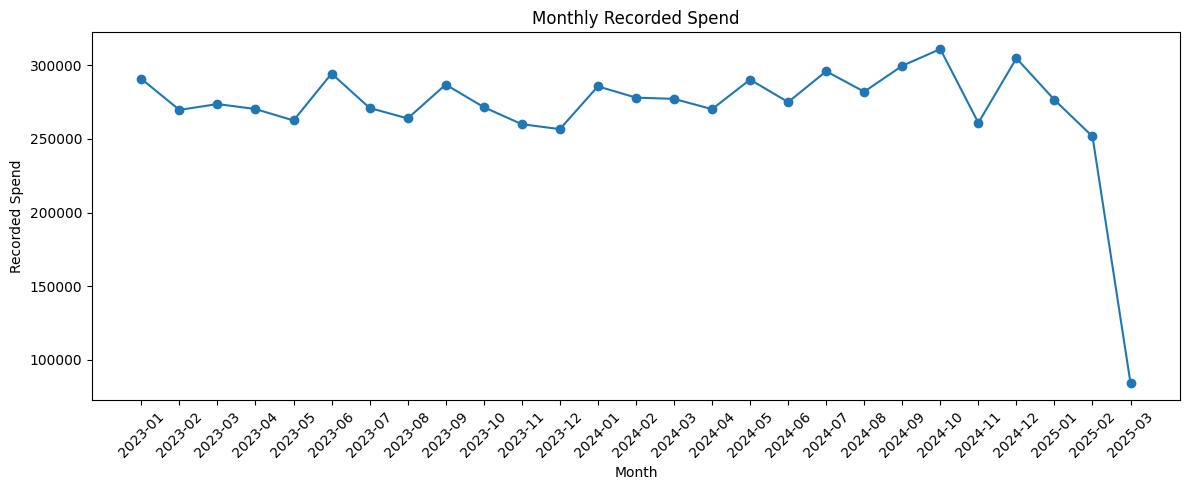

In [18]:
if "monthly" in globals():
    fig, ax = plt.subplots(figsize=(12,5))
    ax.plot(monthly.purchase_month, monthly.Recorded_Spend, marker="o")
    ax.set_title("Monthly Recorded Spend")
    ax.set_xlabel("Month"); ax.set_ylabel("Recorded Spend")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


## 6. Customer Analytics

In [19]:
from IPython.display import display

df["last_purchase_date"] = pd.to_datetime(
    df["last_purchase_date"],
    errors="coerce"
)

customer_metrics = (
    df.groupby("customer_id")
    .agg(
        Recorded_Spend=("total_spent", "sum"),
        Avg_Order_Value=("avg_order_value", "mean"),
        Purchase_Frequency=("last_3_month_purchase_freq", "mean"),
        Recency_Source_Date=("last_purchase_date", "max"),
        Lifetime_Value=("lifetime_value", "mean"),
        Churn=("churn", "mean"),
        Support_Tickets=("support_tickets", "mean"),
        Satisfaction=("satisfaction_score", "mean"),
        NPS=("nps_score", "mean")
    )
    .reset_index()
)

analysis_date = df["last_purchase_date"].max()

customer_metrics["Recency_Days"] = (
    analysis_date - customer_metrics["Recency_Source_Date"]
).dt.days

top_customers = (
    customer_metrics
    .sort_values("Recorded_Spend", ascending=False)
    .head(20)
    .copy()
)

styled_customer_metrics = (
    top_customers.style
    .format({
        "Recorded_Spend": "{:,.2f}",
        "Avg_Order_Value": "{:,.2f}",
        "Purchase_Frequency": "{:.2f}",
        "Lifetime_Value": "{:,.2f}",
        "Churn": "{:.1%}",
        "Support_Tickets": "{:.2f}",
        "Satisfaction": "{:.2f}",
        "NPS": "{:.0f}",
        "Recency_Days": "{:,.0f}"
    }, na_rep="—")
    .background_gradient(
        subset=["Recorded_Spend"],
        cmap="Blues"
    )
    .background_gradient(
        subset=["Lifetime_Value"],
        cmap="Greens"
    )
    .background_gradient(
        subset=["Churn"],
        cmap="Reds"
    )
    .set_properties(**{
        "text-align": "center",
        "padding": "9px",
        "font-size": "11px",
        "border": "1px solid #E6E6E6"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#17365D"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "10px"),
                ("border", "1px solid #D9E2F3")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#F4F7FB")
            ]
        },
        {
            "selector": "tbody tr:hover",
            "props": [
                ("background-color", "#EAF2F8")
            ]
        }
    ])
    .set_caption("Top 20 Customers by Recorded Spend")
)

display(styled_customer_metrics)

,customer_id,Recorded_Spend,Avg_Order_Value,Purchase_Frequency,Recency_Source_Date,Lifetime_Value,Churn,Support_Tickets,Satisfaction,NPS,Recency_Days
12992,22993,"15,910.43",35.19,4.00,2023-02-16 00:00:00,"2,181.40",0.0%,1.00,3.00,10,753
5428,15429,"14,954.75",78.44,14.00,2024-05-30 00:00:00,37.40,0.0%,1.00,5.00,2,284
13147,23148,"14,308.48",90.09,11.00,2024-10-06 00:00:00,87.39,0.0%,0.00,4.00,0,155
14072,24073,"14,230.70",67.84,8.00,2024-04-01 00:00:00,765.13,0.0%,4.00,3.00,3,343
5593,15594,"13,709.77",30.77,7.00,2024-06-15 00:00:00,"1,359.07",0.0%,2.00,5.00,3,268
12211,22212,"12,259.19",62.95,7.00,2024-01-17 00:00:00,999.95,0.0%,2.00,4.00,6,418
6470,16471,"10,925.99",69.94,4.00,2023-06-27 00:00:00,34.95,0.0%,2.00,5.00,1,622
13504,23505,"10,708.43",48.96,11.00,2024-12-31 00:00:00,"1,701.95",0.0%,3.00,4.00,5,69
1192,11193,"9,897.03",93.42,14.00,2024-07-03 00:00:00,"1,555.50",0.0%,3.00,3.00,2,250
11149,21150,"9,049.79",64.66,1.00,2024-06-05 00:00:00,854.55,0.0%,2.00,4.00,10,278


## 7. Proxy RFM Segmentation

In [20]:
from IPython.display import display

rfm = customer_metrics.copy()

rfm["R_score"] = pd.qcut(
    rfm["Recency_Days"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_score"] = pd.qcut(
    rfm["Purchase_Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_score"] = pd.qcut(
    rfm["Recorded_Spend"]
    .fillna(rfm["Recorded_Spend"].median())
    .rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM_score"] = rfm[
    ["R_score", "F_score", "M_score"]
].sum(axis=1)


def rfm_segment(x):
    if x >= 13:
        return "Champions"
    elif x >= 11:
        return "Loyal / High Value"
    elif x >= 9:
        return "Potential Loyalists"
    elif x >= 7:
        return "New / Promising"
    elif x >= 5:
        return "At Risk"
    else:
        return "Hibernating / Lost"


rfm["Segment"] = rfm["RFM_score"].map(rfm_segment)


rfm_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("customer_id", "count"),
        Recorded_Spend=("Recorded_Spend", "sum"),
        Avg_Spend=("Recorded_Spend", "mean"),
        Avg_Frequency=("Purchase_Frequency", "mean"),
        Avg_Recency=("Recency_Days", "mean"),
        Churn_Rate=("Churn", "mean")
    )
    .reset_index()
)

rfm_summary["Customer_Share"] = (
    rfm_summary["Customers"] / rfm_summary["Customers"].sum()
)

rfm_summary["Revenue_Contribution"] = (
    rfm_summary["Recorded_Spend"] /
    rfm_summary["Recorded_Spend"].sum()
)

rfm_summary = rfm_summary.sort_values(
    "Recorded_Spend",
    ascending=False
).reset_index(drop=True)


styled_rfm = (
    rfm_summary.style
    .format({
        "Customers": "{:,.0f}",
        "Recorded_Spend": "{:,.2f}",
        "Avg_Spend": "{:,.2f}",
        "Avg_Frequency": "{:.2f}",
        "Avg_Recency": "{:,.0f}",
        "Churn_Rate": "{:.1%}",
        "Customer_Share": "{:.1%}",
        "Revenue_Contribution": "{:.1%}"
    }, na_rep="—")
    .background_gradient(
        subset=["Recorded_Spend"],
        cmap="Blues"
    )
    .background_gradient(
        subset=["Revenue_Contribution"],
        cmap="Greens"
    )
    .background_gradient(
        subset=["Churn_Rate"],
        cmap="Reds"
    )
    .set_properties(**{
        "text-align": "center",
        "padding": "9px",
        "font-size": "11px",
        "border": "1px solid #E6E6E6"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#17365D"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "10px"),
                ("border", "1px solid #D9E2F3")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#F4F7FB")
            ]
        },
        {
            "selector": "tbody tr:hover",
            "props": [
                ("background-color", "#EAF2F8")
            ]
        }
    ])
    .set_caption("Proxy RFM Customer Segmentation")
)

display(styled_rfm)

,Segment,Customers,Recorded_Spend,Avg_Spend,Avg_Frequency,Avg_Recency,Churn_Rate,Customer_Share,Revenue_Contribution
0,Potential Loyalists,"4,418","2,245,596.34",508.28,7.56,373,14.5%,29.5%,30.7%
1,Loyal / High Value,"3,026","1,984,507.93",655.82,9.32,270,10.8%,20.2%,27.1%
2,New / Promising,"3,965","1,520,428.04",383.46,5.51,479,17.4%,26.4%,20.8%
3,Champions,"1,189","1,020,652.67",858.41,11.43,159,8.6%,7.9%,14.0%
4,At Risk,"1,943","487,378.32",250.84,3.49,579,21.3%,13.0%,6.7%
5,Hibernating / Lost,459,"56,222.40",122.49,1.73,681,28.3%,3.1%,0.8%


## 8. Customer Value & Pareto

In [21]:
customer_value = rfm[["customer_id","Recorded_Spend"]].sort_values("Recorded_Spend", ascending=False).copy()
customer_value["Cumulative_Spend"] = customer_value.Recorded_Spend.cumsum()
customer_value["Cumulative_Share"] = customer_value.Cumulative_Spend / customer_value.Recorded_Spend.sum()

pareto = {}
for p in [.01,.05,.10,.20]:
    n = max(1, math.ceil(len(customer_value)*p))
    pareto[f"Top {p:.0%}"] = customer_value.head(n).Recorded_Spend.sum()/customer_value.Recorded_Spend.sum()
pd.Series(pareto, name="Recorded Spend Share").to_frame()


,Recorded Spend Share
Top 1%,0.051
Top 5%,0.139
Top 10%,0.233
Top 20%,0.398


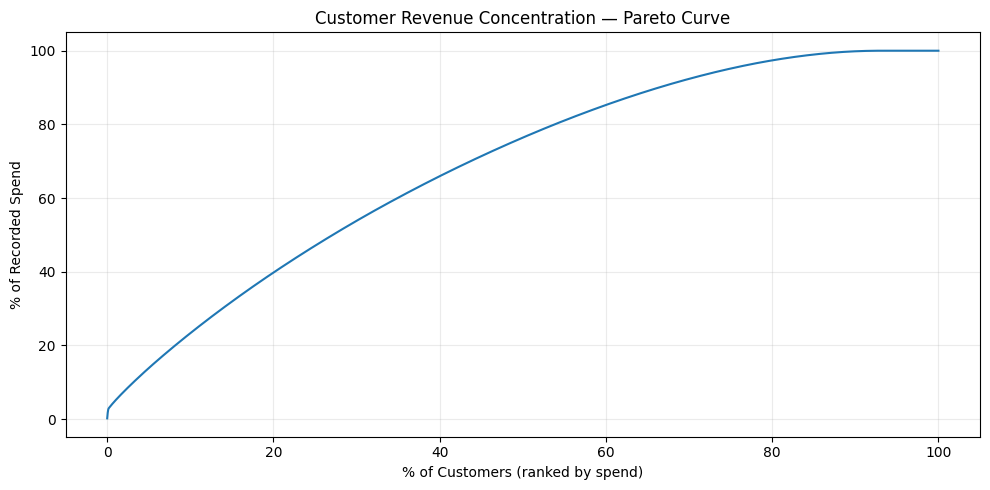

In [22]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(1,len(customer_value)+1)/len(customer_value)*100, customer_value.Cumulative_Share*100)
ax.set_title("Customer Revenue Concentration — Pareto Curve")
ax.set_xlabel("% of Customers (ranked by spend)")
ax.set_ylabel("% of Recorded Spend")
ax.grid(alpha=.25)
plt.tight_layout(); plt.show()


## 9. Marketing Channel Performance

In [23]:
from IPython.display import display, HTML

if "acquisition_channel" in df.columns:

    channel = dimension_summary("acquisition_channel").reset_index()

    best_total = channel.loc[
        channel["Recorded Spend"].idxmax(),
        "acquisition_channel"
    ]

    best_value = channel.loc[
        channel["Avg Spend"].idxmax(),
        "acquisition_channel"
    ]

    styled_channel = (
        channel.style
        .format({
            "Customers": "{:,.0f}",
            "Recorded Spend": "{:,.2f}",
            "Avg Spend": "{:,.2f}",
            "Avg Order Value": "{:,.2f}",
            "Avg LTV": "{:,.2f}",
            "Churn Rate": "{:.1%}",
            "Avg Frequency": "{:.2f}"
        }, na_rep="—")
        .background_gradient(
            subset=["Recorded Spend"],
            cmap="Blues"
        )
        .background_gradient(
            subset=["Avg Spend"],
            cmap="Greens"
        )
        .background_gradient(
            subset=["Churn Rate"],
            cmap="Reds"
        )
        .set_properties(**{
            "text-align": "center",
            "padding": "10px",
            "font-size": "11px",
            "border": "1px solid #E6E6E6"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", "#17365D"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("padding", "10px")
                ]
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [
                    ("background-color", "#F4F7FB")
                ]
            },
            {
                "selector": "tbody tr:hover",
                "props": [
                    ("background-color", "#EAF2F8")
                ]
            }
        ])
        .set_caption("Acquisition Channel Performance")
    )

    display(styled_channel)

    summary = pd.DataFrame({
        "Metric": [
            "Highest Total Recorded Spend",
            "Highest Average Spend per Customer"
        ],
        "Channel": [
            best_total,
            best_value
        ]
    })

    styled_summary = (
        summary.style
        .set_properties(**{
            "text-align": "center",
            "padding": "10px",
            "font-size": "12px",
            "border": "1px solid #E6E6E6"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", "#17365D"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("padding", "10px")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("background-color", "#F4F7FB")
                ]
            }
        ])
        .set_caption("Channel Performance Highlights")
    )

    display(styled_summary)

else:

    print("Not available in the dataset.")

,index,acquisition_channel,Customers,Recorded Spend,Avg Spend,Avg Order Value,Avg LTV,Churn Rate,Avg Frequency
0,0,Organic,"3,055","1,511,907.97",530.68,60.30,"1,232.29",15.9%,7.05
1,1,Google Ads,"3,047","1,503,634.57",528.70,60.59,"1,218.41",15.2%,7.02
2,2,Facebook Ads,"3,024","1,472,526.13",524.03,60.21,"1,236.67",14.8%,6.89
3,3,Email,"2,933","1,424,689.24",524.94,59.88,"1,242.45",15.0%,7.05
4,4,Referral,"2,941","1,402,027.78",513.00,59.40,"1,249.41",15.8%,6.87


,Metric,Channel
0,Highest Total Recorded Spend,Organic
1,Highest Average Spend per Customer,Organic


## 10. Customer Behavior & Product Relationships

In [24]:
from IPython.display import display, HTML

behavior_dimensions = [
    c for c in [
        "acquisition_channel",
        "subscription_type",
        "device_type",
        "gender"
    ]
    if c in df.columns
]

if behavior_dimensions:

    behavior = (
        df.groupby(behavior_dimensions)
        .agg(
            Customers=("customer_id", "nunique"),
            Recorded_Spend=("total_spent", "sum"),
            Avg_Spend=("total_spent", "mean"),
            Avg_Order_Value=("avg_order_value", "mean"),
            Avg_Frequency=("last_3_month_purchase_freq", "mean"),
            Churn_Rate=("churn", "mean")
        )
        .reset_index()
        .sort_values("Recorded_Spend", ascending=False)
        .head(50)
    )

    styled_behavior = (
        behavior.style
        .format({
            "Customers": "{:,.0f}",
            "Recorded_Spend": "{:,.2f}",
            "Avg_Spend": "{:,.2f}",
            "Avg_Order_Value": "{:,.2f}",
            "Avg_Frequency": "{:.2f}",
            "Churn_Rate": "{:.1%}"
        }, na_rep="—")
        .background_gradient(
            subset=["Recorded_Spend"],
            cmap="Blues"
        )
        .background_gradient(
            subset=["Avg_Spend"],
            cmap="Greens"
        )
        .background_gradient(
            subset=["Churn_Rate"],
            cmap="Reds"
        )
        .set_properties(**{
            "text-align": "center",
            "padding": "9px",
            "font-size": "11px",
            "border": "1px solid #E6E6E6"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", "#17365D"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("padding", "10px"),
                    ("border", "1px solid #D9E2F3")
                ]
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [
                    ("background-color", "#F4F7FB")
                ]
            },
            {
                "selector": "tbody tr:hover",
                "props": [
                    ("background-color", "#EAF2F8")
                ]
            }
        ])
        .set_caption("Customer Behavioral Performance Analysis")
    )

    display(styled_behavior)

else:

    display(HTML("""
    <div style="
        background-color:#F4F7FB;
        border-left:5px solid #17365D;
        padding:15px;
        margin:10px 0;
        font-size:14px;
        color:#333;
    ">
        <strong>Behavioral Analysis</strong><br>
        Not available in the dataset.
    </div>
    """))


display(HTML("""
<div style="
    background-color:#F8F9FA;
    border:1px solid #D9E2F3;
    border-radius:6px;
    padding:15px;
    margin-top:20px;
    font-size:14px;
    color:#333;
">
    <strong style="color:#17365D;">
        Product & Customer Relationship Analysis
    </strong>
    <br><br>
    <strong>Status:</strong> Not available in the dataset.
    <br>
    <strong>Reason:</strong> The dataset does not contain product, SKU, category,
    transaction-line, or order-level product fields required for product-level
    relationship, cross-selling, upselling, or market basket analysis.
</div>
"""))

,acquisition_channel,subscription_type,device_type,gender,Customers,Recorded_Spend,Avg_Spend,Avg_Order_Value,Avg_Frequency,Churn_Rate
85,Organic,Monthly,Desktop,Male,252,"144,941.10",619.41,64.16,7.40,12.3%
49,Google Ads,Annual,Desktop,Male,238,"131,621.25",595.57,59.68,7.10,12.2%
21,Email,Monthly,Tablet,Male,242,"131,351.71",573.59,59.04,7.10,14.5%
65,Google Ads,Monthly,Mobile,Male,251,"129,404.78",541.44,59.78,6.83,11.2%
92,Organic,Monthly,Tablet,Female,237,"124,761.09",561.99,58.86,6.88,17.3%
8,Email,Annual,Tablet,Female,232,"124,551.86",584.75,60.70,6.78,13.4%
13,Email,Monthly,Desktop,Male,236,"124,285.41",564.93,58.10,6.91,16.1%
24,Facebook Ads,Annual,Desktop,Female,249,"120,906.92",530.29,61.62,7.16,15.3%
37,Facebook Ads,Monthly,Desktop,Male,229,"119,860.57",552.35,61.40,6.77,14.0%
68,Google Ads,Monthly,Tablet,Female,236,"118,061.40",549.12,59.12,6.80,14.8%


## 12. Retention & Churn

In [25]:
print(f"Observed churn rate: {df.churn.mean():.2%}")
print("Important: churn is analyzed as the supplied churn label; a new churn definition is not invented.")

if "last_3_month_purchase_freq" in df:
    churn_behavior = df.groupby("churn").agg(
        Customers=("customer_id","nunique"),
        Avg_Spend=("total_spent","mean"),
        Avg_Frequency=("last_3_month_purchase_freq","mean"),
        Avg_Recency_Days=("last_purchase_date", lambda s: (analysis_date-s.max()).days if len(s) else np.nan),
        Avg_LTV=("lifetime_value","mean")
    )
    display(churn_behavior)


Observed churn rate: 15.32%
Important: churn is analyzed as the supplied churn label; a new churn definition is not invented.


,Customers,Avg_Spend,Avg_Frequency,Avg_Recency_Days,Avg_LTV
churn,,,,,
0,12702,557.292,6.972,0,"1,233.950"
1,2298,347.791,6.991,0,"1,245.360"


## 13. Statistical Evidence

In [26]:
from IPython.display import display

continuous = [
    c for c in [
        "total_spent",
        "avg_order_value",
        "lifetime_value",
        "last_3_month_purchase_freq",
        "total_visits",
        "email_open_rate",
        "email_click_rate",
        "satisfaction_score",
        "nps_score",
        "support_tickets",
        "delivery_delay_days",
        "marketing_spend_per_user"
    ]
    if c in df.columns
]

tests = []

for c in continuous:

    a = df.loc[df["churn"] == 0, c].dropna()
    b = df.loc[df["churn"] == 1, c].dropna()

    if len(a) > 1 and len(b) > 1:

        t, p = stats.ttest_ind(
            a,
            b,
            equal_var=False
        )

        pooled = np.sqrt(
            (
                (len(a) - 1) * a.var()
                + (len(b) - 1) * b.var()
            )
            / (len(a) + len(b) - 2)
        )

        d_eff = (
            (a.mean() - b.mean()) / pooled
            if pooled != 0
            else np.nan
        )

        tests.append([
            c,
            len(a),
            len(b),
            a.mean(),
            b.mean(),
            t,
            p,
            d_eff
        ])

t_tests = pd.DataFrame(
    tests,
    columns=[
        "Metric",
        "Non-Churn N",
        "Churn N",
        "Mean Non-Churn",
        "Mean Churn",
        "t Statistic",
        "p Value",
        "Cohen's d"
    ]
)

t_tests["Significance"] = np.where(
    t_tests["p Value"] < 0.05,
    "Statistically Significant",
    "Not Significant"
)

t_tests["Business Difference"] = (
    t_tests["Mean Non-Churn"]
    - t_tests["Mean Churn"]
)

t_tests = t_tests.sort_values(
    "p Value",
    ascending=True
).reset_index(drop=True)

styled_t_tests = (
    t_tests.style
    .format({
        "Non-Churn N": "{:,.0f}",
        "Churn N": "{:,.0f}",
        "Mean Non-Churn": "{:,.3f}",
        "Mean Churn": "{:,.3f}",
        "t Statistic": "{:,.3f}",
        "p Value": "{:.4f}",
        "Cohen's d": "{:.3f}",
        "Business Difference": "{:,.3f}"
    }, na_rep="—")
    .background_gradient(
        subset=["p Value"],
        cmap="RdYlGn_r"
    )
    .background_gradient(
        subset=["Cohen's d"],
        cmap="Blues"
    )
    .set_properties(**{
        "text-align": "center",
        "padding": "9px",
        "font-size": "11px",
        "border": "1px solid #E6E6E6"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#17365D"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "10px"),
                ("border", "1px solid #D9E2F3")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#F4F7FB")
            ]
        },
        {
            "selector": "tbody tr:hover",
            "props": [
                ("background-color", "#EAF2F8")
            ]
        }
    ])
    .set_caption(
        "Welch's t-Test: Churned vs Non-Churned Customers"
    )
)

display(styled_t_tests)

,Metric,Non-Churn N,Churn N,Mean Non-Churn,Mean Churn,t Statistic,p Value,Cohen's d,Significance,Business Difference
0,satisfaction_score,"12,702","2,298",3.744,2.856,31.266,0.0000,0.872,Statistically Significant,0.888
1,total_spent,"11,757","2,193",557.292,347.791,27.134,0.0000,0.455,Statistically Significant,209.501
2,support_tickets,"12,702","2,298",1.918,2.423,-12.992,0.0000,-0.358,Statistically Significant,-0.505
3,total_visits,"12,702","2,298",14.979,15.122,-1.613,0.1069,-0.037,Not Significant,-0.143
4,email_open_rate,"12,702","2,298",0.497,0.491,1.036,0.3002,0.023,Not Significant,0.007
5,marketing_spend_per_user,"12,702","2,298",17.598,17.452,0.890,0.3736,0.020,Not Significant,0.146
6,lifetime_value,"12,702","2,298","1,233.950","1,245.360",-0.764,0.4450,-0.017,Not Significant,-11.410
7,nps_score,"12,702","2,298",4.961,5.011,-0.699,0.4845,-0.016,Not Significant,-0.050
8,email_click_rate,"12,702","2,298",0.251,0.251,0.215,0.8297,0.005,Not Significant,0.001
9,last_3_month_purchase_freq,"12,702","2,298",6.972,6.991,-0.196,0.8450,-0.004,Not Significant,-0.019


## 14. Performance Gaps

In [27]:
from IPython.display import display

gap_rows = []

for c, tab in dimension_results.items():

    if "Avg Spend" in tab.columns and len(tab) > 1:

        hi = tab["Avg Spend"].idxmax()
        lo = tab["Avg Spend"].idxmin()

        high_group = tab.loc[hi, c]
        low_group = tab.loc[lo, c]

        high_value = tab.loc[hi, "Avg Spend"]
        low_value = tab.loc[lo, "Avg Spend"]

        absolute_gap = high_value - low_value

        relative_gap = (
            absolute_gap / low_value
            if pd.notna(low_value) and low_value != 0
            else np.nan
        )

        gap_rows.append([
            c,
            high_group,
            low_group,
            high_value,
            low_value,
            absolute_gap,
            relative_gap
        ])


gaps = pd.DataFrame(
    gap_rows,
    columns=[
        "Dimension",
        "Highest Avg Spend Group",
        "Lowest Avg Spend Group",
        "Highest Avg Spend",
        "Lowest Avg Spend",
        "Absolute Gap",
        "Relative Gap"
    ]
)


gaps = gaps.sort_values(
    "Relative Gap",
    ascending=False
).reset_index(drop=True)


styled_gaps = (
    gaps.style
    .format({
        "Highest Avg Spend": "{:,.2f}",
        "Lowest Avg Spend": "{:,.2f}",
        "Absolute Gap": "{:,.2f}",
        "Relative Gap": "{:.1%}"
    }, na_rep="—")
    .background_gradient(
        subset=["Absolute Gap"],
        cmap="Blues"
    )
    .background_gradient(
        subset=["Relative Gap"],
        cmap="Reds"
    )
    .set_properties(**{
        "text-align": "center",
        "padding": "10px",
        "font-size": "11px",
        "border": "1px solid #E6E6E6"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#17365D"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "10px"),
                ("border", "1px solid #D9E2F3")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#F4F7FB")
            ]
        },
        {
            "selector": "tbody tr:hover",
            "props": [
                ("background-color", "#EAF2F8")
            ]
        }
    ])
    .set_caption("Average Customer Spend Performance Gaps")
)

display(styled_gaps)

,Dimension,Highest Avg Spend Group,Lowest Avg Spend Group,Highest Avg Spend,Lowest Avg Spend,Absolute Gap,Relative Gap
0,city,London,Delhi,540.54,512.62,27.92,5.4%
1,country,Bangladesh,UK,534.88,507.54,27.33,5.4%
2,payment_method,BKash,UPI,540.24,517.41,22.83,4.4%
3,acquisition_channel,Organic,Referral,530.68,513.00,17.68,3.4%
4,gender,Unknown,Other,527.70,511.54,16.16,3.2%
5,device_type,Desktop,Tablet,530.80,518.66,12.15,2.3%
6,subscription_type,Annual,Monthly,529.37,519.59,9.78,1.9%


*Note: the checks below re-run on `df` after the cleaning in Section 2b. Lower counts here than in the original Data Quality Report (Section 2) are expected -- they confirm the cleaning was applied, not a discrepancy.*


## 15. Root Cause Analysis — Evidence-Based Diagnostic Layer

In [28]:
rca = []

negative_dates = int((df.last_purchase_date < df.signup_date).sum())
missing_spend = int(df.total_spent.isna().sum())
age_bad = int(((df.age<13)|(df.age>100)).sum())
promo_mismatch = int((df.coupon_code.notna() != (df.discount_used==1)).sum())

rca.append(["Lifecycle chronology",negative_dates,
            "last_purchase_date < signup_date",
            "Tenure/cohort calculations are unreliable for affected records.",
            "Validate source chronology; exclude affected records from lifecycle timing."])
rca.append(["Revenue completeness",missing_spend,
            "missing total_spent",
            "Recorded-spend totals and Pareto shares are based on non-missing spend.",
            "Report coverage; investigate source; do not blindly impute."])
rca.append(["Age quality",age_bad,
            "age < 13 or > 100",
            "Age segmentation can be distorted.",
            "Correct or exclude from age-specific analysis."])
rca.append(["Promotion semantics",promo_mismatch,
            "coupon presence disagrees with discount flag",
            "Promotion fields cannot safely be interpreted as equivalent.",
            "Validate business definitions before campaign/promotion conclusions."])

pd.DataFrame(rca, columns=["Problem","Affected Records","Evidence","Diagnostic Interpretation","Action"])


,Problem,Affected Records,Evidence,Diagnostic Interpretation,Action
0,Lifecycle chronology,3762,last_purchase_date < signup_date,Tenure/cohort calculations are unreliable for ...,Validate source chronology; exclude affected r...
1,Revenue completeness,1050,missing total_spent,Recorded-spend totals and Pareto shares are ba...,Report coverage; investigate source; do not bl...
2,Age quality,0,age < 13 or > 100,Age segmentation can be distorted.,Correct or exclude from age-specific analysis.
3,Promotion semantics,7624,coupon presence disagrees with discount flag,Promotion fields cannot safely be interpreted ...,Validate business definitions before campaign/...


## 16. Advanced Business Insights

In [29]:
top20 = pareto["Top 20%"]
top10 = pareto["Top 10%"]
top_channel = (
    channel.loc[channel["Recorded Spend"].idxmax(), "acquisition_channel"]
    if "channel" in globals() else "Not available"
)
value_channel = (
    channel.loc[channel["Avg Spend"].idxmax(), "acquisition_channel"]
    if "channel" in globals() else "Not available"
)
highest_rfm_churn = rfm_summary.loc[rfm_summary.Churn_Rate.idxmax()]

insights = [
    ["Customer concentration",
     f"Top 20% contribute {top20:.1%} of recorded spend; top 10% contribute {top10:.1%}.",
     "Revenue is materially concentrated among higher-value customers.",
     "Prioritize high-value retention while monitoring concentration risk."],
    ["Channel scale vs value",
     f"{top_channel} leads total recorded spend, while {value_channel} leads average spend/customer.",
     "The highest-volume/value channel is not necessarily the same channel.",
     "Evaluate channels on scale, value/customer and churn together."],
    ["RFM targeting",
     f"The highest-churn proxy RFM segment is {highest_rfm_churn.Segment} at {highest_rfm_churn.Churn_Rate:.1%}.",
     "This identifies a potentially high-priority retention group, not a causal churn driver.",
     "Use the segment for controlled retention targeting and testing."],
    ["Data integrity",
     f"{negative_dates:,} records have invalid purchase/signup chronology.",
     "Lifecycle and cohort insights could be materially misleading.",
     "Repair source logic before using tenure/cohort results."],
    ["Analytical scope",
     "Product and campaign analyses are not available in the dataset.",
     "Product/campaign winners and ROI cannot be evidenced from this file.",
     "Integrate product-line and campaign-response data."]
]
pd.DataFrame(insights, columns=["Insight","Evidence","Business Meaning","Recommended Action"])


,Insight,Evidence,Business Meaning,Recommended Action
0,Customer concentration,Top 20% contribute 39.8% of recorded spend; to...,Revenue is materially concentrated among highe...,Prioritize high-value retention while monitori...
1,Channel scale vs value,"Organic leads total recorded spend, while Orga...",The highest-volume/value channel is not necess...,"Evaluate channels on scale, value/customer and..."
2,RFM targeting,The highest-churn proxy RFM segment is Hiberna...,This identifies a potentially high-priority re...,Use the segment for controlled retention targe...
3,Data integrity,"3,762 records have invalid purchase/signup chr...",Lifecycle and cohort insights could be materia...,Repair source logic before using tenure/cohort...
4,Analytical scope,Product and campaign analyses are not availabl...,Product/campaign winners and ROI cannot be evi...,Integrate product-line and campaign-response d...


## 16b. Modeling -- Segmentation & Churn Prediction

Two lightweight, evidence-grounded models: unsupervised customer segmentation (KMeans) to
cross-check the proxy-RFM segments, and a baseline churn classifier for directional feature
signal. Neither is presented as causal or production-ready -- both are diagnostic tools that
feed the action plan below.


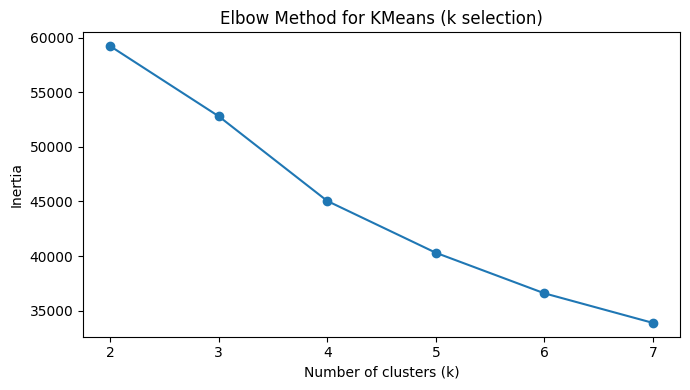

,total_spent,avg_order_value,last_3_month_purchase_freq,lifetime_value,recency_days,Customers
cluster,,,,,,
0,513.920,59.059,3.081,"1,197.456",558.262,4330
1,"10,535.135",55.171,7.118,"1,310.056",340.824,17
2,503.867,60.852,11.133,"1,281.098",538.596,4261
3,517.304,60.325,6.822,"1,230.745",159.204,5342


In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = [c for c in ["total_spent", "avg_order_value", "last_3_month_purchase_freq",
                                 "lifetime_value", "recency_days"] if c in df.columns]
cluster_data = df[cluster_features].dropna().copy()

scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_data[cluster_features])

inertia = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(scaled)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertia, marker="o")
ax.set_title("Elbow Method for KMeans (k selection)")
ax.set_xlabel("Number of clusters (k)"); ax.set_ylabel("Inertia")
plt.tight_layout(); plt.show()

k_final = 4
km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10).fit(scaled)
cluster_data["cluster"] = km_final.labels_

cluster_profile = cluster_data.groupby("cluster")[cluster_features].mean()
cluster_profile["Customers"] = cluster_data.groupby("cluster").size()
cluster_profile

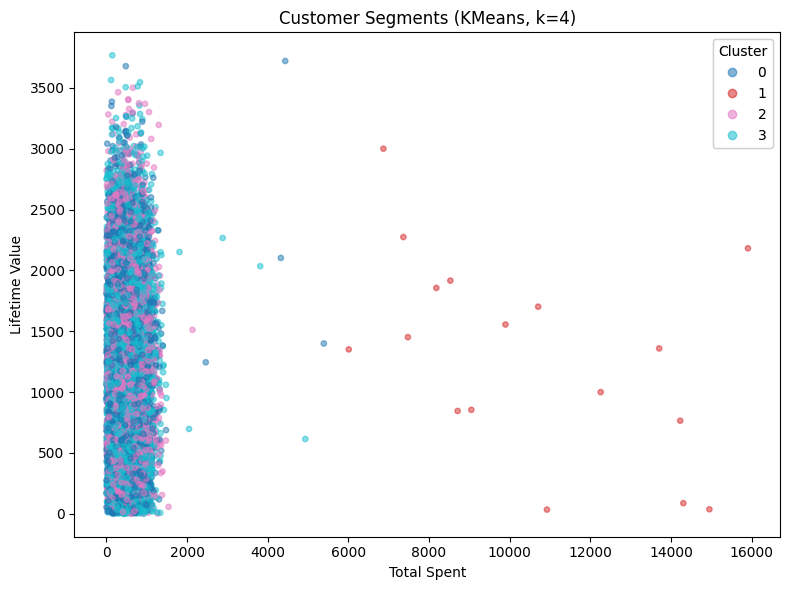

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(cluster_data["total_spent"], cluster_data["lifetime_value"],
                      c=cluster_data["cluster"], cmap="tab10", alpha=.5, s=15)
ax.set_xlabel("Total Spent"); ax.set_ylabel("Lifetime Value")
ax.set_title(f"Customer Segments (KMeans, k={k_final})")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout(); plt.show()

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

model_num_cols = [c for c in [
    "age", "total_visits", "avg_session_time", "pages_per_session", "email_open_rate",
    "email_click_rate", "avg_order_value", "support_tickets", "delivery_delay_days",
    "satisfaction_score", "nps_score", "marketing_spend_per_user",
    "last_3_month_purchase_freq", "total_spent", "lifetime_value"
] if c in df.columns]
model_cat_cols = [c for c in ["acquisition_channel", "device_type", "subscription_type",
                               "payment_method", "gender"] if c in df.columns]

model_df = df[model_num_cols + model_cat_cols + ["churn"]].copy()
for c in model_num_cols:
    model_df[c] = model_df[c].fillna(model_df[c].median())

X = pd.get_dummies(model_df[model_num_cols + model_cat_cols], columns=model_cat_cols, drop_first=True)
y = model_df["churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler2 = StandardScaler()
X_train_s = scaler2.fit_transform(X_train)
X_test_s = scaler2.transform(X_test)

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train_s, y_train)
y_pred = clf.predict(X_test_s)
y_proba = clf.predict_proba(X_test_s)[:, 1]

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Value": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba),
    ]
})
metrics_table

,Metric,Value
0,Accuracy,0.752
1,Precision,0.354
2,Recall,0.743
3,F1 Score,0.479
4,ROC-AUC,0.823


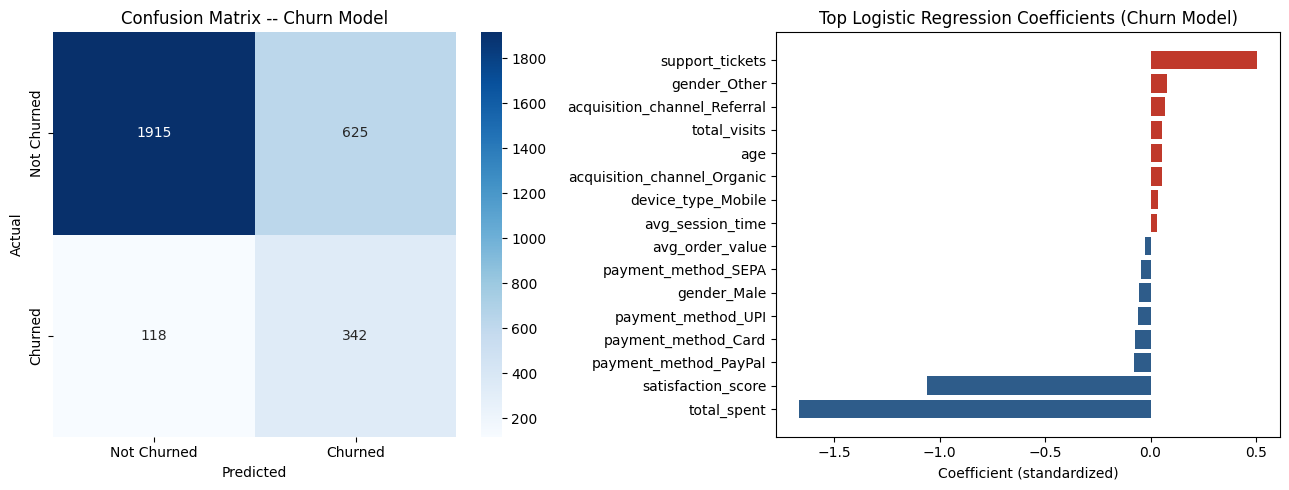

Note: this is a baseline, directional model (which factors move with churn), not a causal or production-ready predictor.


In [33]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Not Churned", "Churned"], yticklabels=["Not Churned", "Churned"])
axes[0].set_title("Confusion Matrix -- Churn Model")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

coefs = pd.Series(clf.coef_[0], index=X.columns).sort_values()
top_coefs = pd.concat([coefs.head(8), coefs.tail(8)])
axes[1].barh(top_coefs.index, top_coefs.values,
             color=np.where(top_coefs.values > 0, "#C0392B", "#2E5C8A"))
axes[1].set_title("Top Logistic Regression Coefficients (Churn Model)")
axes[1].set_xlabel("Coefficient (standardized)")
plt.tight_layout(); plt.show()

print("Note: this is a baseline, directional model (which factors move with churn), "
      "not a causal or production-ready predictor.")

## 17. Marketing Opportunity Matrix & Action Plan

In [34]:
actions = pd.DataFrame([
    ["Immediate","Fix date chronology",f"{negative_dates:,} invalid chronology records","Data integrity",
     "Validate source logic and exclude affected records from lifecycle metrics.","High"],
    ["Immediate","Clarify promotion semantics",f"{promo_mismatch:,} coupon/discount mismatches","Promotion measurement",
     "Document source definitions before promotion optimization.","High"],
    ["Immediate","Protect high-value customers",f"Top 20% = {top20:.1%} of recorded spend","Revenue concentration",
     "Deploy RFM + churn-based retention priorities.","High"],
    ["Short-Term","Optimize channel allocation","Observed differences in channel spend/value/churn","Channel value",
     "Evaluate investment using scale, customer value and risk jointly.","Medium-High"],
    ["Medium-Term","Add product-level data","No product identifiers or transaction lines","Product intelligence gap",
     "Integrate transaction-line/product data.","High"],
    ["Medium-Term","Add campaign-level data","No campaign identifier/response table","Campaign intelligence gap",
     "Integrate campaign spend, reach, response and conversion data.","High"]
], columns=["Priority","Business Problem","Evidence","Driver/Indicator","Recommended Action","Expected Impact"])
actions


,Priority,Business Problem,Evidence,Driver/Indicator,Recommended Action,Expected Impact
0,Immediate,Fix date chronology,"3,762 invalid chronology records",Data integrity,Validate source logic and exclude affected rec...,High
1,Immediate,Clarify promotion semantics,"7,624 coupon/discount mismatches",Promotion measurement,Document source definitions before promotion o...,High
2,Immediate,Protect high-value customers,Top 20% = 39.8% of recorded spend,Revenue concentration,Deploy RFM + churn-based retention priorities.,High
3,Short-Term,Optimize channel allocation,Observed differences in channel spend/value/churn,Channel value,"Evaluate investment using scale, customer valu...",Medium-High
4,Medium-Term,Add product-level data,No product identifiers or transaction lines,Product intelligence gap,Integrate transaction-line/product data.,High
5,Medium-Term,Add campaign-level data,No campaign identifier/response table,Campaign intelligence gap,"Integrate campaign spend, reach, response and ...",High


## 18. KPI Dictionary

In [35]:
kpi_dictionary = pd.DataFrame([
    ["Total Recorded Spend","Sum of available total_spent","SUM(total_spent)","Observed spend","total_spent"],
    ["Customers","Unique customer IDs","COUNT(DISTINCT customer_id)","Customer base","customer_id"],
    ["Average Order Value","Mean of avg_order_value","AVERAGE(avg_order_value)","Order-value proxy","avg_order_value"],
    ["Repeat Purchase Rate","Share with 3-month frequency > 1","COUNT(freq>1)/customers","Repeat behavior proxy","last_3_month_purchase_freq"],
    ["Observed Churn Rate","Mean of supplied churn flag","SUM(churn)/customers","Observed churn label","churn"],
    ["CAC","Not available in the dataset.","—","No validated acquisition-cost field","—"],
    ["ROAS","Not available in the dataset.","—","No campaign-level attributable spend/revenue","—"],
    ["Campaign Conversion","Not available in the dataset.","—","No campaign-response table","—"],
    ["Product Revenue","Not available in the dataset.","—","No product/transaction-line table","—"],
    ["CLV","Provided lifetime_value field","Use supplied field","Existing field, not a newly modeled CLV","lifetime_value"]
], columns=["KPI","Definition","Formula","Business Meaning","Data Source"])
kpi_dictionary


,KPI,Definition,Formula,Business Meaning,Data Source
0,Total Recorded Spend,Sum of available total_spent,SUM(total_spent),Observed spend,total_spent
1,Customers,Unique customer IDs,COUNT(DISTINCT customer_id),Customer base,customer_id
2,Average Order Value,Mean of avg_order_value,AVERAGE(avg_order_value),Order-value proxy,avg_order_value
3,Repeat Purchase Rate,Share with 3-month frequency > 1,COUNT(freq>1)/customers,Repeat behavior proxy,last_3_month_purchase_freq
4,Observed Churn Rate,Mean of supplied churn flag,SUM(churn)/customers,Observed churn label,churn
5,CAC,Not available in the dataset.,—,No validated acquisition-cost field,—
6,ROAS,Not available in the dataset.,—,No campaign-level attributable spend/revenue,—
7,Campaign Conversion,Not available in the dataset.,—,No campaign-response table,—
8,Product Revenue,Not available in the dataset.,—,No product/transaction-line table,—
9,CLV,Provided lifetime_value field,Use supplied field,"Existing field, not a newly modeled CLV",lifetime_value


In [36]:
import os
import pandas as pd

output_dir = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
cleaned_csv_path = os.path.join(
    output_dir,
    "cleaned_marketing_customer_dataset.csv"
)
cleaned_excel_path = os.path.join(
    output_dir,
    "cleaned_marketing_customer_dataset.xlsx"
)

cleaned_df = df.copy()

cleaned_df.to_csv(
    cleaned_csv_path,
    index=False
)

cleaned_df.to_excel(
    cleaned_excel_path,
    index=False,
    sheet_name="Cleaned Data"
)

print("Cleaned data saved successfully.")
print(f"CSV: {cleaned_csv_path}")
print(f"Excel: {cleaned_excel_path}")
print(f"Shape: {cleaned_df.shape}")

Cleaned data saved successfully.
CSV: /kaggle/working/cleaned_marketing_customer_dataset.csv
Excel: /kaggle/working/cleaned_marketing_customer_dataset.xlsx
Shape: (15000, 41)
